# Backtest 005 — TTM Breakout Squeeze

Notebook implementation of `BreakoutTTMVersion2` from `backend/app/services/strategies/breakout_ttm.py`.

## Strategy logic

| Version | Entry condition |
|---------|----------------|
| **v1** | `no_squeeze` AND `TTM momentum > 0` |
| **v2** | `no_squeeze` AND `TTM momentum crossed above 0` (up to 3 bars look-back) |
| **v3** | Squeeze JUST released AND (`momentum > 0` OR `consecutive_neg > threshold`) OR Williams VIX Fix signal |

**Exit:** ATR trailing stop (multiplier optimised via Optuna)

**Optimisation:** Multi-objective Optuna — maximise `Total Return (%)` and `Sortino Ratio`

In [235]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [236]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake …')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

# ── extract OHLCV DataFrames (dates × symbols) ────────────────────────────────
open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2500, 198)  |  2016-04-04 00:00:00 → 2026-04-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-01,7.08,14.7,23.799999,46.900002,8.63,13.00,14.90,23.85,5.59,5.72,...,1705.739990,61.299999,12.80,26.799999,4.24,58.400002,27.549999,24.250000,99.400002,10.15
2026-04-02,7.00,14.5,23.600000,46.400002,8.56,12.85,14.65,23.75,5.55,5.64,...,1695.130005,60.799999,12.65,26.250000,4.15,58.200001,27.200001,24.299999,98.300003,10.00
2026-04-03,6.94,14.5,23.500000,45.799999,8.54,12.55,14.60,23.60,5.53,5.59,...,1684.089966,60.000000,12.50,25.799999,4.02,58.000000,26.500000,23.799999,93.599998,9.94


## 2. TTM Breakout Helpers

In [237]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────

@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    """Shift a 2-D array along axis 0 (time axis)."""
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    """Count consecutive negative values per column (used for TTM momentum bars)."""
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    """
    Kaufman's Adaptive Moving Average applied column-wise.
    - Efficiency Ratio (ER) = |close - close[period]| / sum(|diff(close)|, period)
    - Smoothing Constant (SC) = (ER * (fast_sc - slow_sc) + slow_sc)^2
    - KAMA[i] = KAMA[i-1] + SC * (close[i] - KAMA[i-1])
    When market is trending (ER -> 1), SC -> fast_sc (tracks quickly).
    When market is choppy   (ER -> 0), SC -> slow_sc (barely moves).
    """
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    """
    Returns a boolean 2-D mask that is True where the KAMA line is
    'flat': |pct change over slope_window bars| < flat_threshold_pct.
    First slope_window rows are always False.
    """
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')


Numba helpers compiled


In [238]:
def compute_signals(
    close, high, low,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout — gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) — NOT gated
      v3 WVF    : volatility spike / contrarian — NOT gated
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # ── indicators → numpy ────────────────────────────────────────────────────
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period,
        mult=bb_multiplier,
        bbl=bb_window,
        lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    # ── KAMA flat-slope mask (computed once, reused across versions) ───────────
    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)  # all True → no filtering

    # ── v1: squeeze no-fire + positive momentum → full KAMA gate ──────────────
    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    # ── v2: momentum just crossed above 0 → full KAMA gate ────────────────────
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    # ── v3: entry_1 (breakout) gated; entry_2 + WVF (bottom fishing) free ─────
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)

        # breakout on squeeze release — only when KAMA is flat
        entry_1 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (ttms_np > 0)
            & flat_np
        )
        # bottom fishing: extended negative momentum — no KAMA filter
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        # WVF: volatility spike / contrarian — no KAMA filter
        entries_np = entry_1 | entry_2 | wvf_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings used as explicit exit signals.
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


## 3. Baseline Run (default params, entry v3)

In [239]:
print('Computing baseline signals (v3, default params) …')
entries_base = compute_signals(
    close, high, low,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3',
    consecutive_neg_threshold=7,
    william_vix_period=20,
)
exits_base, sl_stop_base = compute_exits(close, high, low, atr_multiplier=1.9)

print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base,
    exits=exits_base,
    sl_stop=sl_stop_base,
    freq='1d',
    group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)


Computing baseline signals (v3, default params) …
Entry signals: 13,123

Baseline portfolio stats:


Start                                2016-04-04 00:00:00
End                                  2026-04-03 00:00:00
Period                                2500 days 00:00:00
Start Value                                        100.0
End Value                                     304.815896
Total Return [%]                              204.815896
Benchmark Return [%]                          259.869576
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               44.700006
Max Drawdown Duration                  916 days 16:00:00
Total Trades                                   53.106061
Total Closed Trades                            52.479798
Total Open Trades                               0.626263
Open Trade PnL                                  3.653158
Win Rate [%]                                   39.173964
Best Trade [%]                                 65.039975
Worst Trade [%]                

---
## 4. Per-Version Optimisation — v1, v2, v3 Separate Studies

Each version gets its own Optuna study so parameter spaces can be tuned
independently.  v3 has extra params (`consecutive_neg_threshold`, `william_vix_period`);
v1/v2 share the same space.

| Study | Entry logic | Extra params |
|-------|------------|--------------|
| `study_v1` | `no_squeeze & TTM > 0` | — |
| `study_v2` | `no_squeeze & TTM crossed above 0` (±2 bars) | — |
| `study_v3` | squeeze released & (TTM>0 OR consec_neg>thr) OR WVF | `consecutive_neg_threshold`, `william_vix_period` |

In [240]:
def make_objective(version: str):
    """
    Returns an Optuna objective function fixed to `version`.
    Objectives: (Total Return %, Sortino Ratio)
    """
    def objective(trial):
        bb_window            = trial.suggest_int  ('bb_window',           10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',       0.8, 2.0, step=0.1)
        kc_window            = trial.suggest_int  ('kc_window',           20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',       0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',       5, 20)
        donichan_window      = trial.suggest_int  ('donichan_window',     8, 25)
        osc_smoothing_period = trial.suggest_int  ('osc_smoothing_period',5, 20)

        atr_period           = trial.suggest_int  ('atr_period',          5, 20)
        atr_multiplier       = trial.suggest_float('atr_multiplier',      1.2, 3.5, step=0.1)
        low_stop_lookback     = trial.suggest_int  ('low_stop_lookback',   3, 20)

        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',       14, 30)

        # KAMA slope filter params
        kama_period        = trial.suggest_int  ('kama_period',        5, 20)
        kama_fast          = trial.suggest_int  ('kama_fast',          2, 5)
        kama_slow          = trial.suggest_int  ('kama_slow',          20, 50)
        kama_slope_win     = trial.suggest_int  ('kama_slope_win',     3, 20)
        flat_threshold_pct = trial.suggest_float('flat_threshold_pct', 1, 3.0, step=0.1)

        try:
            entries = compute_signals(
                close, high, low,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=0,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period,
                donichan_window=donichan_window,
                osc_smoothing_period=osc_smoothing_period,
                entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
                use_kama_slope=True,
                kama_period=kama_period,
                kama_fast=kama_fast,
                kama_slow=kama_slow,
                kama_slope_win=kama_slope_win,
                flat_threshold_pct=flat_threshold_pct,
            )
            exits, sl_stop_df = compute_exits(
                close, high, low,
                atr_multiplier=atr_multiplier, atr_period=atr_period,
                low_stop_lookback=low_stop_lookback,
            )

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )

            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()

            if len(total_ret) == 0:
                return -999.0, -999.0

            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0

            # penalise if <30% of symbols profitable
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5

            return mean_ret, mean_sort

        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 500   # raise for better coverage

studies = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n── Optimising {ver} ({N_TRIALS_PER_VERSION} trials) ──────────────────────')
    s = optuna.create_study(
        directions   = ['maximize', 'maximize'],
        study_name   = f'ttm_{ver}',
        sampler      = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')



── Optimising v1 (500 trials) ──────────────────────


  0%|          | 0/500 [00:00<?, ?it/s]

  Pareto front: 5 trials

── Optimising v2 (500 trials) ──────────────────────


  0%|          | 0/500 [00:00<?, ?it/s]

  Pareto front: 5 trials

── Optimising v3 (500 trials) ──────────────────────


  0%|          | 0/500 [00:00<?, ?it/s]

  Pareto front: 4 trials

All studies done.


## 5. Select Best Params per Version

In [241]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    # balanced
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trials = {ver: pick_best(studies[ver]) for ver in ['v1', 'v2', 'v3']}
best_params = {ver: t.params for ver, t in best_trials.items()}

summary_rows = []
for ver, trial in best_trials.items():
    row = {'Version': ver,
           'Trial #': trial.number,
           'Total Return (%)': round(trial.values[0], 2),
           'Sortino':          round(trial.values[1], 3)}
    row.update(trial.params)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Version')
print(f'Selection strategy: {SELECTION}')
display(summary_df)


Selection strategy: balanced


,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,kc_window,kc_multiplier,kc_atr_period,donichan_window,osc_smoothing_period,atr_period,atr_multiplier,low_stop_lookback,consecutive_neg_threshold,william_vix_period,kama_period,kama_fast,kama_slow,kama_slope_win,flat_threshold_pct
Version,,,,,,,,,,,,,,,,,,,,
v1,453,403.27,0.995,14,1.0,51,1.2,7,9,11,11,3.5,5,14,22,10,4,23,4,2.8
v2,493,397.55,1.001,18,1.2,53,1.5,5,9,11,5,2.5,7,13,27,9,3,25,3,2.8
v3,238,403.07,0.981,11,1.1,30,1.5,7,20,15,5,2.9,8,9,18,20,4,47,14,1.6


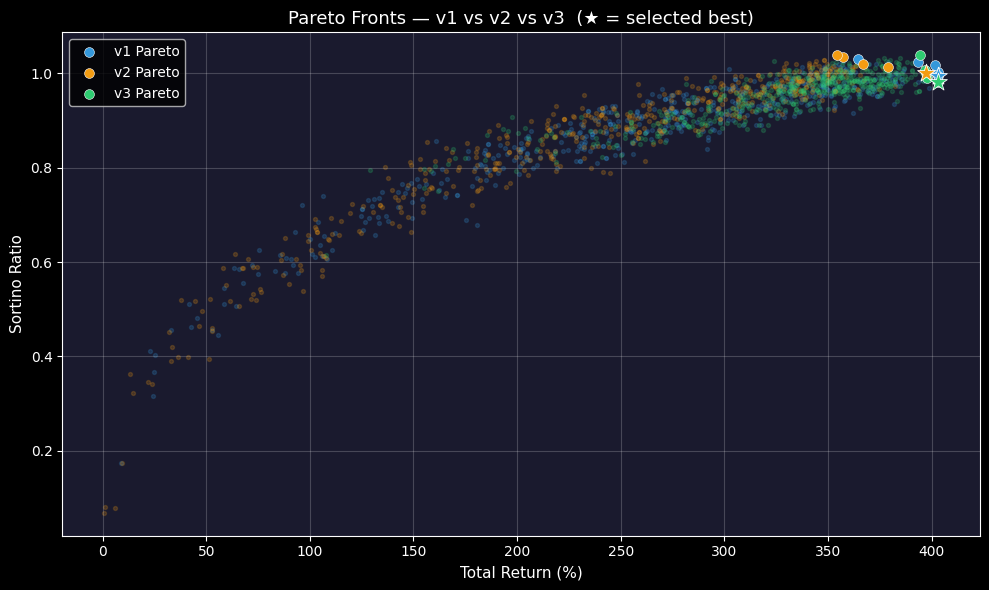

In [242]:
# ── Pareto fronts of all 3 versions on one chart ─────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

for ver, study in studies.items():
    col = COLORS[ver]
    # background: all trials
    all_vals = [(t.values[0], t.values[1]) for t in study.trials
                if t.values and t.values[0] > -900]
    if all_vals:
        ax.scatter(*zip(*all_vals), c=col, s=8, alpha=0.2)
    # Pareto front
    pf_vals = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter(*zip(*pf_vals), c=col, s=50, zorder=5,
               edgecolors='white', linewidths=0.4, label=f'{ver} Pareto')
    # best point
    bt = best_trials[ver]
    ax.scatter(bt.values[0], bt.values[1], c=col, s=180, marker='*',
               zorder=6, edgecolors='white', linewidths=0.6)

ax.set_xlabel('Total Return (%)', fontsize=11)
ax.set_ylabel('Sortino Ratio',    fontsize=11)
ax.set_title('Pareto Fronts — v1 vs v2 vs v3  (★ = selected best)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


## 6. Final Backtest — Optimised v1 vs v2 vs v3

In [243]:
portfolios = {}

for ver in ['v1', 'v2', 'v3']:
    p  = best_params[ver]
    print(f'Running optimised {ver} …')
    entries = compute_signals(
        close, high, low,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = 0,
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p['donichan_window'],
        osc_smoothing_period     = p['osc_smoothing_period'],
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period',        20),
        use_kama_slope           = True,
        kama_period              = p.get('kama_period',              10),
        kama_fast                = p.get('kama_fast',                 2),
        kama_slow                = p.get('kama_slow',                30),
        kama_slope_win           = p.get('kama_slope_win',            5),
        flat_threshold_pct       = p.get('flat_threshold_pct',        1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier   = p['atr_multiplier'],
        low_stop_lookback= p.get('low_stop_lookback', 5),
    )
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('\nAll done.')


Running optimised v1 …
  signals=101,597  trades=8,163
Running optimised v2 …
  signals=39,093  trades=9,242
Running optimised v3 …
  signals=18,632  trades=9,463

All done.


## 7. Comparison — Stats Table

In [244]:
def version_stats(ver, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Version':          ver,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Total Ret median': f'{pf.total_return().median():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
    }

rows = [version_stats(ver, pf) for ver, pf in portfolios.items()]
# also add baseline
rows.insert(0, version_stats('baseline (v3 default)', pf_base))

comp_df = pd.DataFrame(rows).set_index('Version')
print('=== VERSION COMPARISON ===')
display(comp_df.T)


=== VERSION COMPARISON ===


Version,baseline (v3 default),v1,v2,v3
Sharpe mean,0.554,0.648,0.636,0.613
Sharpe median,0.55,0.719,0.666,0.603
Sharpe > 0,187/198,187/198,186/198,190/198
Sharpe > 1,24/198,30/198,30/198,32/198
Sortino mean,0.864,0.999,0.994,0.97
Calmar mean,0.349,0.447,0.439,0.388
Total Ret mean,204.8%,409.6%,387.3%,370.5%
Total Ret median,117.6%,271.1%,189.6%,191.6%
Max DD mean,-44.7%,-48.8%,-45.9%,-50.8%
Max DD worst,-85.0%,-93.6%,-85.7%,-92.8%


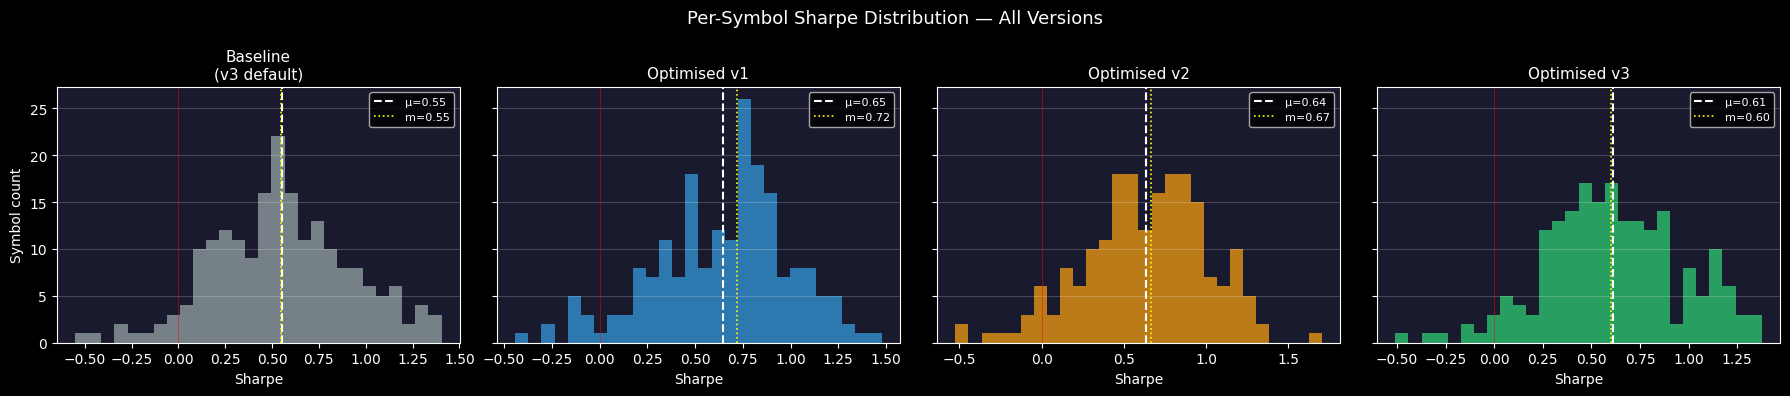

In [245]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

entries_list = [('Baseline\n(v3 default)', pf_base, '#95a5a6')] + [
    (f'Optimised {ver}', portfolios[ver], COLORS[ver])
    for ver in ['v1', 'v2', 'v3']
]

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='--',
               label=f'μ={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
               label=f'm={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Distribution — All Versions', fontsize=13)
fig.tight_layout(); plt.show()


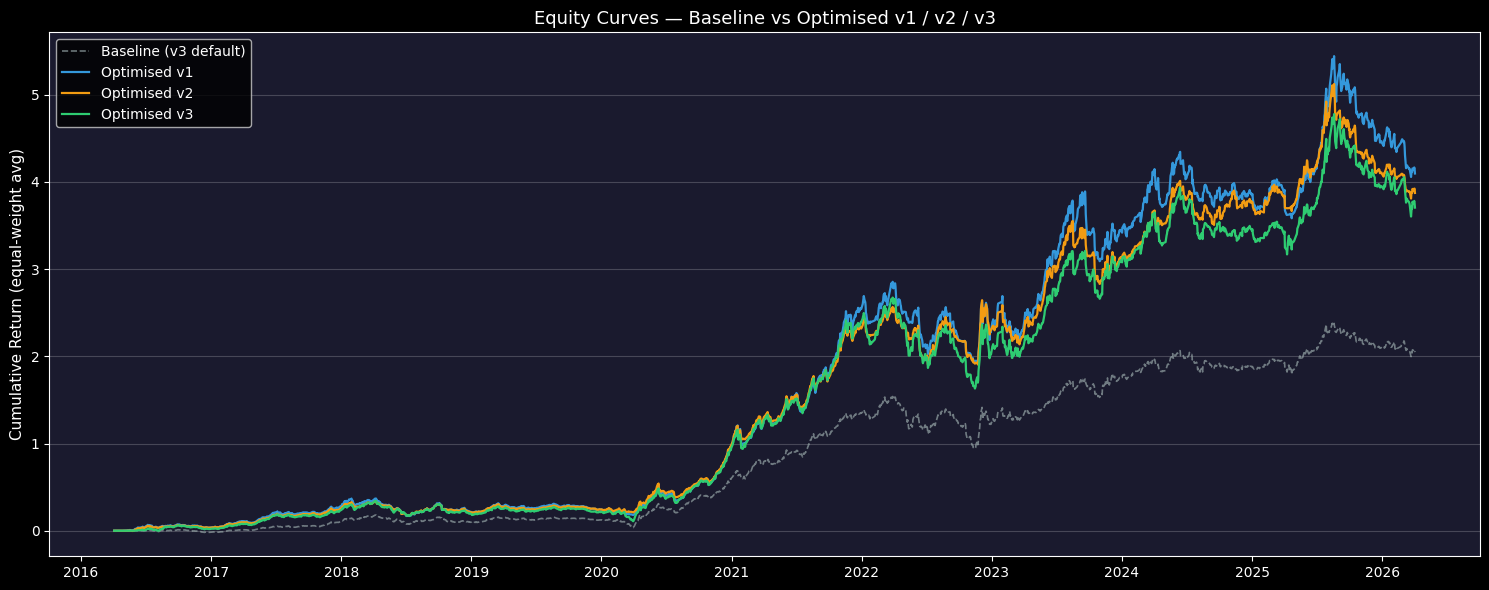

In [246]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

ax.plot(*zip(*[(d, v) for d, v in zip(
    pf_base.cumulative_returns().mean(axis=1).index,
    pf_base.cumulative_returns().mean(axis=1).values
)]), color='#95a5a6', lw=1.2, ls='--', label='Baseline (v3 default)', alpha=0.7)

for ver, pf in portfolios.items():
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=f'Optimised {ver}',
            color=COLORS[ver], lw=1.6)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_title('Equity Curves — Baseline vs Optimised v1 / v2 / v3', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


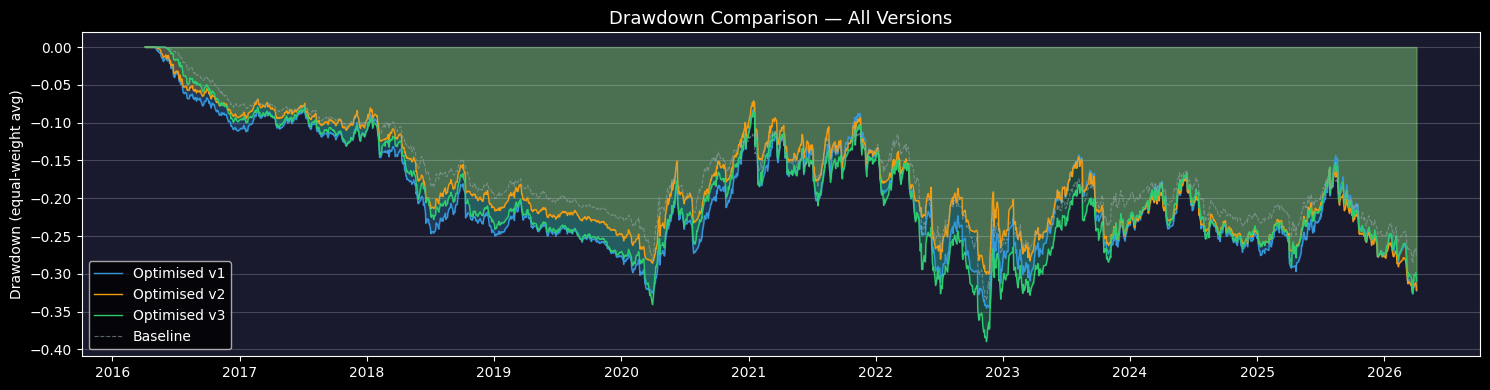

In [247]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_facecolor('#1a1a2e')

for ver, pf in portfolios.items():
    dd = pf.drawdown().mean(axis=1)
    ax.fill_between(dd.index, dd.values, 0,
                    alpha=0.25, color=COLORS[ver])
    ax.plot(dd.index, dd.values, color=COLORS[ver], lw=1.0, label=f'Optimised {ver}')

# baseline
dd_base = pf_base.drawdown().mean(axis=1)
ax.plot(dd_base.index, dd_base.values, color='#95a5a6', lw=0.8, ls='--',
        alpha=0.6, label='Baseline')

ax.set_ylabel('Drawdown (equal-weight avg)')
ax.set_title('Drawdown Comparison — All Versions', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


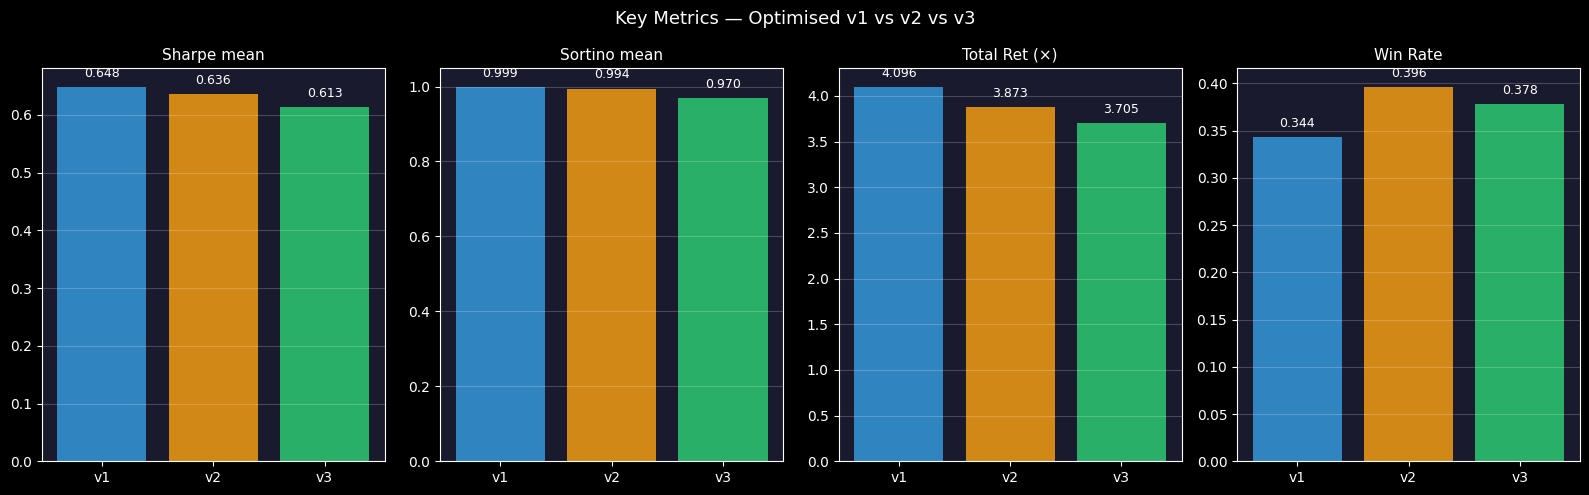

In [248]:
# ── grouped bar chart: Sharpe mean, Sortino mean, Total Ret mean ──────────────
versions  = ['v1', 'v2', 'v3']
metrics   = {
    'Sharpe mean':  [portfolios[v].sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Sortino mean': [portfolios[v].sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Total Ret (×)': [portfolios[v].total_return().mean() for v in versions],
    'Win Rate':     [portfolios[v].trades.win_rate().mean() for v in versions],
}

x   = np.arange(len(versions))
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, vals) in zip(axes, metrics.items()):
    colors = [COLORS[v] for v in versions]
    bars   = ax.bar(versions, vals, color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.axhline(0, color='white', lw=0.6, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2)
    ax.set_facecolor('#1a1a2e')

fig.suptitle('Key Metrics — Optimised v1 vs v2 vs v3', fontsize=13)
fig.tight_layout(); plt.show()


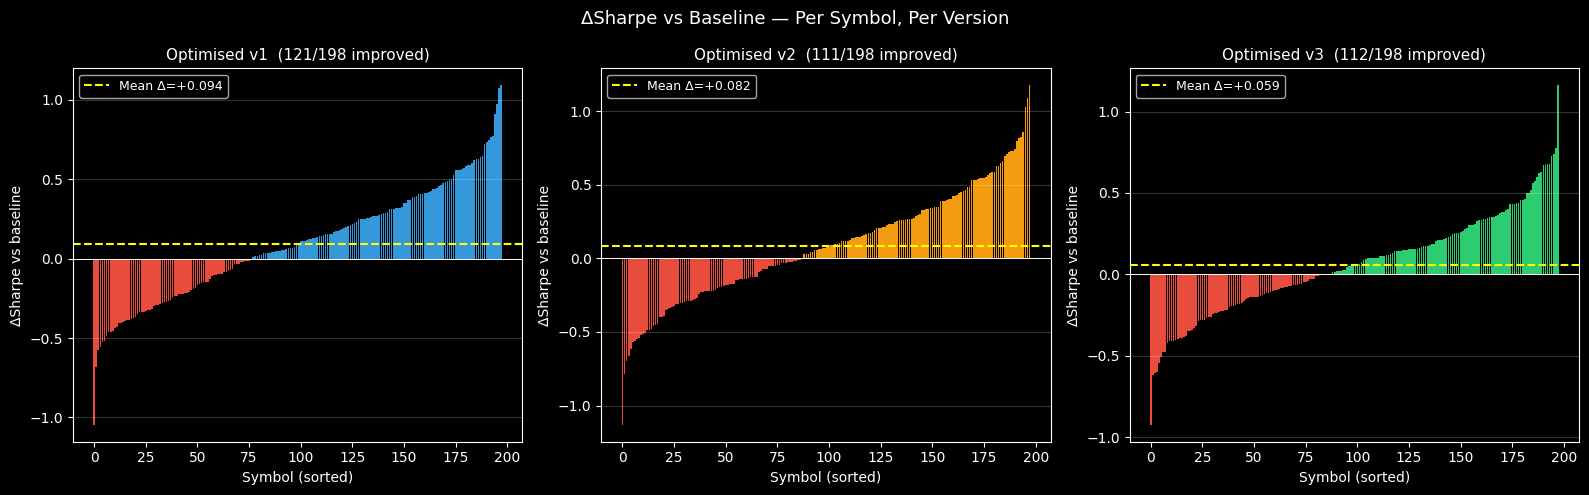

In [249]:
# ── ΔSharpe vs baseline for each version ─────────────────────────────────────
sharpe_base_sym = pf_base.sharpe_ratio().replace([np.inf,-np.inf], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    delta = (portfolios[ver].sharpe_ratio().replace([np.inf,-np.inf], np.nan)
             - sharpe_base_sym).dropna().sort_values()
    bar_colors = [COLORS[ver] if v >= 0 else '#e74c3c' for v in delta]
    ax.bar(range(len(delta)), delta.values, color=bar_colors, edgecolor='none')
    ax.axhline(0, color='white', lw=0.7)
    ax.axhline(delta.mean(), color='yellow', lw=1.5, ls='--',
               label=f'Mean Δ={delta.mean():+.3f}')
    improved = (delta > 0).sum()
    ax.set_title(f'Optimised {ver}  ({improved}/{len(delta)} improved)', fontsize=11)
    ax.set_xlabel('Symbol (sorted)'); ax.set_ylabel('ΔSharpe vs baseline')
    ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('ΔSharpe vs Baseline — Per Symbol, Per Version', fontsize=13)
fig.tight_layout(); plt.show()


In [250]:
# ── final scorecard ───────────────────────────────────────────────────────────
print('=' * 62)
print('  FINAL SCORECARD — OPTIMISED v1 / v2 / v3')
print('=' * 62)
print(f'  {"Version":<12}  {"Sharpe μ":>9}  {"Sortino μ":>10}  {"Total Ret μ":>12}  {"Win Rate":>9}')
print('  ' + '-' * 58)

scores = []
for ver, pf in portfolios.items():
    sh = pf.sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    so = pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    tr = pf.total_return().mean()
    wr = pf.trades.win_rate().mean()
    scores.append((ver, sh, so, tr, wr))
    print(f'  {ver:<12}  {sh:>9.3f}  {so:>10.3f}  {tr:>12.1%}  {wr:>9.1%}')

print('=' * 62)
best_ver = max(scores, key=lambda x: x[1])
print(f'\n  Best Sharpe  → {best_ver[0]}  ({best_ver[1]:.3f})')
best_ret = max(scores, key=lambda x: x[3])
print(f'  Best Return  → {best_ret[0]}  ({best_ret[3]:.1%})')
best_so  = max(scores, key=lambda x: x[2])
print(f'  Best Sortino → {best_so[0]}  ({best_so[2]:.3f})')


  FINAL SCORECARD — OPTIMISED v1 / v2 / v3
  Version        Sharpe μ   Sortino μ   Total Ret μ   Win Rate
  ----------------------------------------------------------
  v1                0.648       0.999        409.6%      34.4%
  v2                0.636       0.994        387.3%      39.6%
  v3                0.613       0.970        370.5%      37.8%

  Best Sharpe  → v1  (0.648)
  Best Return  → v1  (409.6%)
  Best Sortino → v1  (0.999)


## 8. Save Results to HDF5

In [251]:
h5_file   = '../backend/assets/backtest_results_005.h5'
close_syms = set(close.columns)

# ── trades ────────────────────────────────────────────────────────────────────
trades_df = pf_opt.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp']).dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp']).dt.strftime('%Y-%m-%d')

# ── per-symbol stats ──────────────────────────────────────────────────────────
all_metrics = list(pf_opt.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_opt.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

# ── best params ───────────────────────────────────────────────────────────────
params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file, key='trades',     mode='w')
stats_df.to_hdf(h5_file,  key='stats',      mode='a')
params_df.to_hdf(h5_file, key='best_params', mode='a')

print(f'Saved {len(trades_df):,} trades  →  {h5_file}')
print(f'Saved stats for {len(stats_df)} symbols')
print(f'Saved best params ({len(best)} keys)')

trades_df.head()

Saved 8,521 trades  →  ../backend/assets/backtest_results_005.h5
Saved stats for 198 symbols
Saved best params (12 keys)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(3.3, 10, AAA)",9.860704,2016-05-04,10.141264,0.0,2016-09-13,15.317534,0.0,51.041670,0.510417,Long,Closed,0,AAA
1,1,"(3.3, 10, AAA)",9.254383,2016-09-28,16.321096,0.0,2016-11-02,15.317534,0.0,-9.287346,-0.061489,Long,Closed,1,AAA
2,2,"(3.3, 10, AAA)",8.975823,2016-11-21,15.792906,0.0,2016-12-01,14.894981,0.0,-8.059610,-0.056856,Long,Closed,2,AAA
3,3,"(3.3, 10, AAA)",9.964995,2017-01-06,13.416436,0.0,2017-01-18,12.731924,0.0,-6.821160,-0.051020,Long,Closed,3,AAA
4,4,"(3.3, 10, AAA)",9.817209,2017-02-08,12.923587,0.0,2017-10-30,17.860754,0.0,48.469202,0.382028,Long,Closed,4,AAA


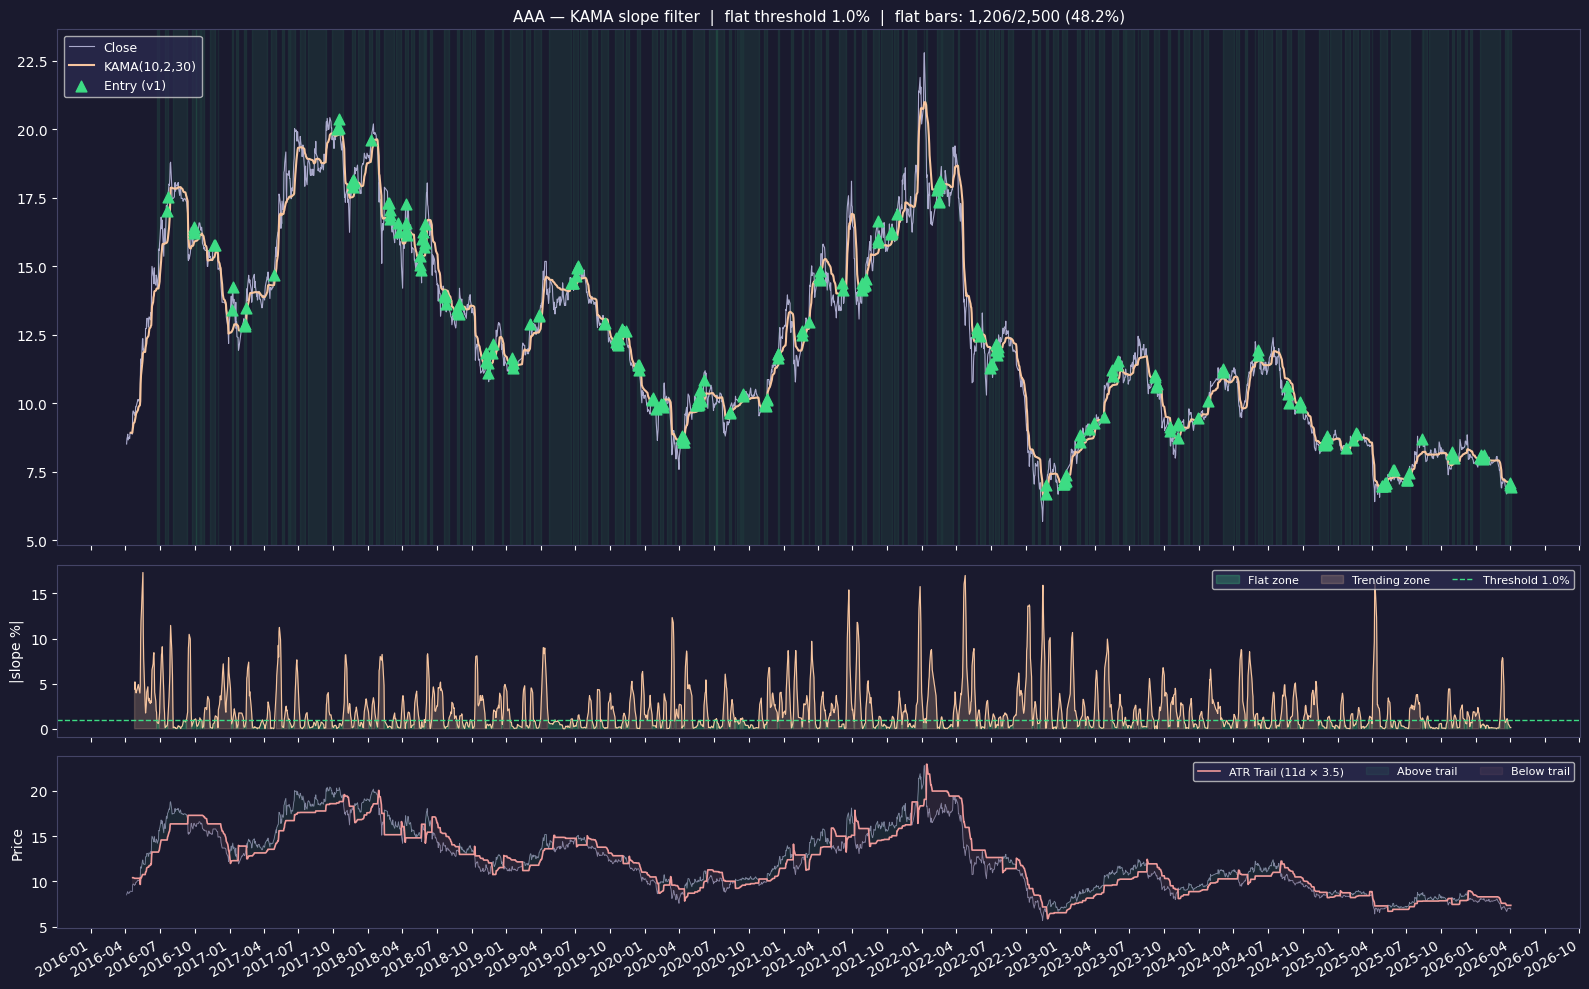

Entry signals (v1): 239 signals on AAA


In [252]:
# ── KAMA Slope Visual Inspection ─────────────────────────────────────────────
# Panel 1: Close price + KAMA line + flat-slope shading + entry signals
# Panel 2: |KAMA slope %| with flatness threshold
# Panel 3: ATR trailing stop
# Run Section 2 (helpers) first so kama_2d / slope_flat_2d are defined.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ── Config — edit these ───────────────────────────────────────────────────────
INSPECT_SYM    = close.columns[0]   # symbol to inspect
KAMA_PERIOD    = 10
KAMA_FAST      = 2
KAMA_SLOW      = 30
SLOPE_WIN      = 5
FLAT_PCT       = 1.0
ATR_PERIOD     = 11
ATR_MULT       = 3.5
SHOW_ENTRIES   = True               # overlay entry signals on price chart
ENTRY_VERSION  = 'v1'               # 'v1' | 'v2' | 'v3'
# ─────────────────────────────────────────────────────────────────────────────

close_1d = close[[INSPECT_SYM]].to_numpy().astype(np.float64)
high_1d  = high [[INSPECT_SYM]].to_numpy().astype(np.float64)
low_1d   = low  [[INSPECT_SYM]].to_numpy().astype(np.float64)

kama_np = kama_2d(close_1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
flat_np = slope_flat_2d(kama_np, SLOPE_WIN, FLAT_PCT)
flat_mask = flat_np[:, 0]

# ATR trailing stop (reuse trailing_sl from backend)
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../backend').resolve()))
from app.services.indicators.trailing_sl import trailing_sl
import talib as _talib

atr_raw   = _talib.ATR(high_1d[:, 0], low_1d[:, 0], close_1d[:, 0], timeperiod=ATR_PERIOD)
atr_trail = trailing_sl(close_1d[:, 0], atr_raw, atr_multiplier=ATR_MULT)

# Entry signals for this symbol
if SHOW_ENTRIES:
    _entries_df = compute_signals(
        close[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]],
        entry_version=ENTRY_VERSION,
        use_kama_slope=True,
        kama_period=KAMA_PERIOD, kama_fast=KAMA_FAST, kama_slow=KAMA_SLOW,
        kama_slope_win=SLOPE_WIN, flat_threshold_pct=FLAT_PCT,
    )
    entry_dates = _entries_df.index[_entries_df[INSPECT_SYM].values]
    entry_prices = close[INSPECT_SYM].reindex(entry_dates).values

# pct slope
pct_slope = np.full(len(kama_np), np.nan)
for i in range(SLOPE_WIN, len(kama_np)):
    prev = kama_np[i - SLOPE_WIN, 0]
    if prev != 0 and not np.isnan(prev):
        pct_slope[i] = abs((kama_np[i, 0] - prev) / prev * 100.0)

# ── Plot ──────────────────────────────────────────────────────────────────────
idx_range = close.index
DARK = '#1a1a2e'

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor(DARK)
for ax in axes:
    ax.set_facecolor(DARK)
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white')
    ax.yaxis.label.set_color('white')

ax1, ax2, ax3 = axes

# ── Panel 1: Price + KAMA + flat shading + entries ───────────────────────────
# Flat-slope shading (vectorised for speed)
flat_changes = np.where(np.diff(flat_mask.astype(int)) != 0)[0] + 1
boundaries   = [0] + list(flat_changes) + [len(flat_mask)]
for start, end in zip(boundaries[:-1], boundaries[1:]):
    if flat_mask[start]:
        ax1.axvspan(idx_range[start], idx_range[min(end, len(idx_range)-1)],
                    color='#3ddc84', alpha=0.08)

ax1.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.8, label='Close')
ax1.plot(idx_range, kama_np[:, 0], color='#f7c59f', lw=1.5,
         label=f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW})')

if SHOW_ENTRIES and len(entry_dates):
    ax1.scatter(entry_dates, entry_prices, marker='^', color='#3ddc84',
                s=60, zorder=5, label=f'Entry ({ENTRY_VERSION})')

ax1.set_title(
    f'{INSPECT_SYM} — KAMA slope filter  |  flat threshold {FLAT_PCT}%  |  '
    f'flat bars: {flat_mask.sum():,}/{len(flat_mask):,} ({flat_mask.mean()*100:.1f}%)',
    color='white', fontsize=11,
)
ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)

# ── Panel 2: |KAMA slope %| ───────────────────────────────────────────────────
above = pct_slope >= FLAT_PCT
ax2.fill_between(idx_range, pct_slope, 0,
                 where=~above, color='#3ddc84', alpha=0.25, label='Flat zone')
ax2.fill_between(idx_range, pct_slope, 0,
                 where=above,  color='#f7c59f', alpha=0.20, label='Trending zone')
ax2.plot(idx_range, pct_slope, color='#f7c59f', lw=0.8)
ax2.axhline(FLAT_PCT, color='#3ddc84', lw=1, ls='--', label=f'Threshold {FLAT_PCT}%')
ax2.set_ylabel('|slope %|', color='white')
ax2.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=3)

# ── Panel 3: ATR trailing stop ────────────────────────────────────────────────
ax3.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.6, alpha=0.7)
ax3.plot(idx_range, atr_trail, color='#ef9a9a', lw=1.2, label=f'ATR Trail ({ATR_PERIOD}d × {ATR_MULT})')
above_trail = close[INSPECT_SYM].values > atr_trail
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=above_trail,  color='#3ddc84', alpha=0.07, label='Above trail')
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=~above_trail, color='#ef9a9a', alpha=0.07, label='Below trail')
ax3.set_ylabel('Price', color='white')
ax3.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=3)

# ── X axis ────────────────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

plt.tight_layout()
plt.show()

if SHOW_ENTRIES:
    print(f"Entry signals ({ENTRY_VERSION}): {len(entry_dates)} signals on {INSPECT_SYM}")


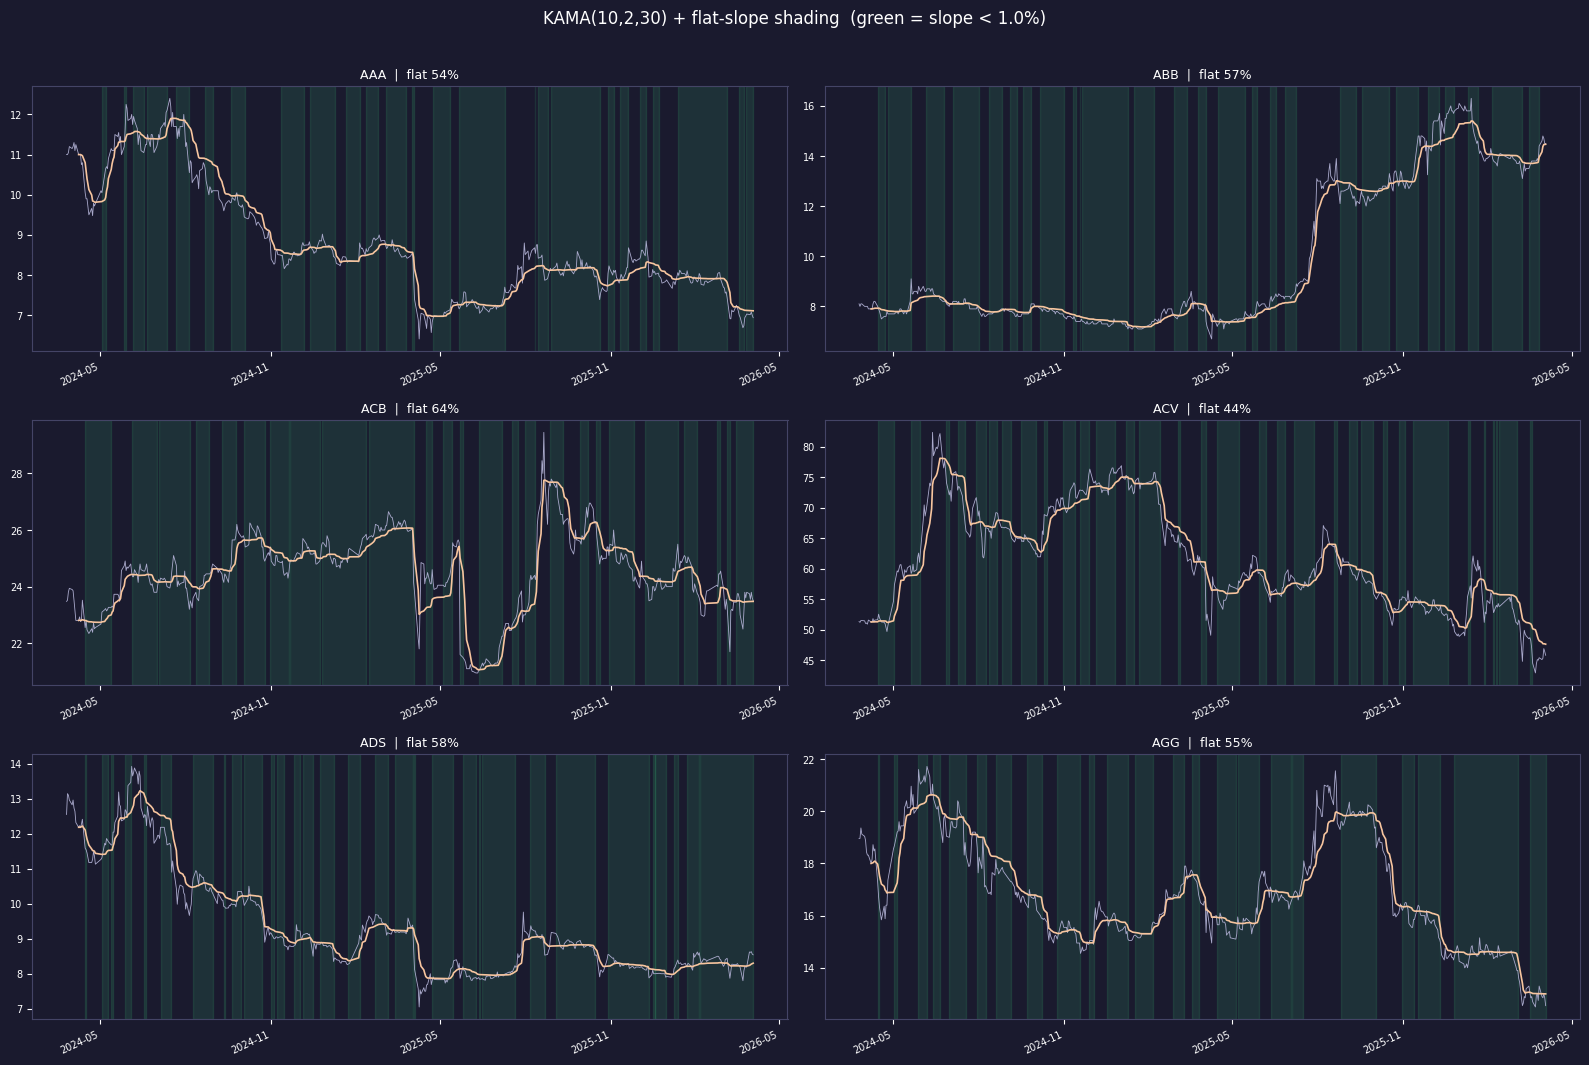

In [253]:
# ── Multi-Symbol KAMA Grid ────────────────────────────────────────────────────
# Shows KAMA + flat shading for up to N_GRID symbols in a grid layout.

N_GRID      = 6          # symbols to display
GRID_SYMS   = close.columns[:N_GRID].tolist()   # or specify: ['ACB','VCB',...]
KAMA_PERIOD = 10
KAMA_FAST   = 2
KAMA_SLOW   = 30
SLOPE_WIN   = 5
FLAT_PCT    = 1.0
LOOKBACK    = 504        # bars to show (None = all)

ncols = 2
nrows = (len(GRID_SYMS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes = axes.flatten() if nrows * ncols > 1 else [axes]
fig.patch.set_facecolor('#1a1a2e')

for ax, sym in zip(axes, GRID_SYMS):
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white', labelsize=7)

    c1d = close[[sym]].to_numpy().astype(np.float64)
    if LOOKBACK:
        c1d = c1d[-LOOKBACK:]
    idx_s = close.index[-len(c1d):]

    kama_s = kama_2d(c1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
    flat_s = slope_flat_2d(kama_s, SLOPE_WIN, FLAT_PCT)[:, 0]

    # shade flat regions (vectorised)
    changes = np.where(np.diff(flat_s.astype(int)) != 0)[0] + 1
    bounds  = [0] + list(changes) + [len(flat_s)]
    for s, e in zip(bounds[:-1], bounds[1:]):
        if flat_s[s]:
            ax.axvspan(idx_s[s], idx_s[min(e, len(idx_s)-1)],
                       color='#3ddc84', alpha=0.12)

    ax.plot(idx_s, c1d[:, 0],     color='#aaaacc', lw=0.6)
    ax.plot(idx_s, kama_s[:, 0],  color='#f7c59f', lw=1.2)

    flat_pct = flat_s.mean() * 100
    ax.set_title(f'{sym}  |  flat {flat_pct:.0f}%', color='white', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

# Hide unused axes
for ax in axes[len(GRID_SYMS):]:
    ax.set_visible(False)

fig.suptitle(
    f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW}) + flat-slope shading  '
    f'(green = slope < {FLAT_PCT}%)',
    color='white', fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


In [254]:
# ══════════════════════════════════════════════════════════════════════════════
# Smart Money Flow Cloud [BOSWaves] — Python port of the Pine Script indicator
# ══════════════════════════════════════════════════════════════════════════════

def _alma_1d(series: np.ndarray, period: int, offset: float, sigma: float) -> np.ndarray:
    """Arnaud Legoux Moving Average (1-D numpy)."""
    m = offset * (period - 1)
    s = period / sigma
    w = np.exp(-((np.arange(period) - m) ** 2) / (2 * s * s))
    w /= w.sum()
    out = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        out[i] = np.dot(w, series[i - period + 1 : i + 1])
    return out


def smart_money_flow_cloud(
    open_df: pd.DataFrame,
    high_df: pd.DataFrame,
    low_df:  pd.DataFrame,
    close_df:pd.DataFrame,
    vol_df:  pd.DataFrame,
    # Core trend
    trend_len:    int   = 34,
    basis_type:   str   = 'EMA',   # 'EMA' | 'ALMA'
    alma_offset:  float = 0.85,
    alma_sigma:   float = 6.0,
    basis_smooth: int   = 3,
    # Smart Money Flow
    mf_len:    int   = 24,
    mf_smooth: int   = 5,
    mf_power:  float = 1.2,
    # Adaptive bands
    atr_len:  int   = 14,
    min_mult: float = 0.9,
    max_mult: float = 2.2,
    # Retest dot cooldown
    dot_cooldown: int = 12,
) -> dict:
    """
    Python port of Smart Money Flow Cloud [BOSWaves].

    Returns a dict of DataFrames (same shape as inputs):
      b_open, b_close       — basis cloud lines
      upper, lower          — adaptive bands
      mf_smooth             — normalised smart money flow  [-1, 1]
      strength              — flow strength                [0, 1]
      mult                  — adaptive ATR multiplier
      last_signal           — 1 = bull, -1 = bear (state machine)
      switch_up/down        — buy/sell signal bars
      bull_dot/bear_dot     — retest dots (with cooldown)
      strength_signed       — tanh-scaled trend strength  [-1, 1]
    """
    results = {}
    syms = close_df.columns

    for sym in syms:
        o = open_df[sym].values.astype(np.float64)
        h = high_df[sym].values.astype(np.float64)
        l = low_df[sym].values.astype(np.float64)
        c = close_df[sym].values.astype(np.float64)
        v = vol_df[sym].values.astype(np.float64)
        n = len(c)
        idx = close_df.index

        # ── Basis ────────────────────────────────────────────────────────────
        if basis_type == 'ALMA':
            raw_o = _alma_1d(o, trend_len, alma_offset, alma_sigma)
            raw_c = _alma_1d(c, trend_len, alma_offset, alma_sigma)
        else:
            raw_o = pd.Series(o, index=idx).ewm(span=trend_len, adjust=False).mean().values
            raw_c = pd.Series(c, index=idx).ewm(span=trend_len, adjust=False).mean().values

        if basis_smooth > 1:
            b_o = pd.Series(raw_o, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
            b_c = pd.Series(raw_c, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
        else:
            b_o, b_c = raw_o, raw_c

        b_main = b_c

        # ── Smart Money Flow ─────────────────────────────────────────────────
        hl = h - l
        clv = np.where(hl == 0, 0.0, ((c - l) - (h - c)) / hl)
        raw_flow = clv * v

        mf_num = pd.Series(raw_flow, index=idx).rolling(mf_len).sum().values
        mf_den = pd.Series(np.abs(raw_flow), index=idx).rolling(mf_len).sum().values
        mf_raw = np.where(mf_den == 0, 0.0, mf_num / mf_den)

        mf_sm = (pd.Series(mf_raw, index=idx).ewm(span=mf_smooth, adjust=False).mean().values
                 if mf_smooth > 1 else mf_raw)

        strength = np.clip(np.power(np.abs(mf_sm), mf_power), 0.0, 1.0)
        mult     = min_mult + (max_mult - min_mult) * strength

        # ── Adaptive bands ───────────────────────────────────────────────────
        atr    = talib.ATR(h, l, c, timeperiod=atr_len)
        upper  = b_main + atr * mult
        lower  = b_main - atr * mult

        # ── Signal state machine ─────────────────────────────────────────────
        long_cond  = (np.roll(c, 1) <= np.roll(upper, 1)) & (c > upper)
        short_cond = (np.roll(c, 1) >= np.roll(lower, 1)) & (c < lower)
        long_cond[0] = short_cond[0] = False

        last_sig = np.zeros(n, dtype=np.int8)
        last_sig[0] = 1 if c[0] >= b_main[0] else -1
        for i in range(1, n):
            if long_cond[i]:   last_sig[i] =  1
            elif short_cond[i]:last_sig[i] = -1
            else:               last_sig[i] = last_sig[i - 1]

        switch_up   = (last_sig ==  1) & (np.roll(last_sig, 1) == -1)
        switch_down = (last_sig == -1) & (np.roll(last_sig, 1) ==  1)
        switch_up[0] = switch_down[0] = False

        # ── Retest dots with cooldown ────────────────────────────────────────
        bear_cond = (last_sig == -1) & (h > b_c)
        bull_cond = (last_sig ==  1) & (l < b_c)
        bear_dot  = np.zeros(n, dtype=bool)
        bull_dot  = np.zeros(n, dtype=bool)
        last_bear = last_bull = -dot_cooldown - 1
        for i in range(n):
            if bear_cond[i] and (dot_cooldown == 0 or i - last_bear >= dot_cooldown):
                bear_dot[i] = True; last_bear = i
            if bull_cond[i] and (dot_cooldown == 0 or i - last_bull >= dot_cooldown):
                bull_dot[i] = True; last_bull = i

        # ── Trend strength (tanh-scaled) ─────────────────────────────────────
        mintick = 0.01
        up_span = np.maximum(upper - b_main, mintick)
        dn_span = np.maximum(b_main - lower, mintick)
        raw_str = np.where(last_sig == 1,
                           (c - b_main) / up_span,
                           -(b_main - c) / dn_span)
        x = np.clip(raw_str * 1.5, -10, 10)
        v_tanh = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
        str_signed = pd.Series(v_tanh, index=idx).ewm(span=3, adjust=False).mean().values

        results[sym] = {
            'b_open':         pd.Series(b_o,         index=idx),
            'b_close':        pd.Series(b_c,         index=idx),
            'upper':          pd.Series(upper,        index=idx),
            'lower':          pd.Series(lower,        index=idx),
            'mf_smooth':      pd.Series(mf_sm,        index=idx),
            'strength':       pd.Series(strength,     index=idx),
            'mult':           pd.Series(mult,         index=idx),
            'last_signal':    pd.Series(last_sig,     index=idx),
            'switch_up':      pd.Series(switch_up,    index=idx),
            'switch_down':    pd.Series(switch_down,  index=idx),
            'bull_dot':       pd.Series(bull_dot,     index=idx),
            'bear_dot':       pd.Series(bear_dot,     index=idx),
            'strength_signed':pd.Series(str_signed,   index=idx),
        }

    return results


print('smart_money_flow_cloud() defined')


smart_money_flow_cloud() defined


In [255]:
# ── Smart Money Flow Cloud — Visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
INSPECT_SYM  = close.columns[0]   # symbol to inspect
TREND_LEN    = 34
BASIS_TYPE   = 'EMA'              # 'EMA' | 'ALMA'
BASIS_SMOOTH = 3
MF_LEN       = 24
MF_SMOOTH    = 5
MF_POWER     = 1.2
ATR_LEN      = 14
MIN_MULT     = 0.9
MAX_MULT     = 2.2
DOT_COOLDOWN = 12
LOOKBACK     = 504                # bars to show (None = all)
# ─────────────────────────────────────────────────────────────────────────────

# Compute for single symbol
_res = smart_money_flow_cloud(
    open_[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]],
    close[[INSPECT_SYM]], volume[[INSPECT_SYM]],
    trend_len=TREND_LEN, basis_type=BASIS_TYPE, basis_smooth=BASIS_SMOOTH,
    mf_len=MF_LEN, mf_smooth=MF_SMOOTH, mf_power=MF_POWER,
    atr_len=ATR_LEN, min_mult=MIN_MULT, max_mult=MAX_MULT,
    dot_cooldown=DOT_COOLDOWN,
)[INSPECT_SYM]

# Slice to LOOKBACK
if LOOKBACK:
    sl = slice(-LOOKBACK, None)
    _r = {k: v.iloc[sl] for k, v in _res.items()}
    _c = close[INSPECT_SYM].iloc[sl]
    _h = high[INSPECT_SYM].iloc[sl]
    _l = low[INSPECT_SYM].iloc[sl]
else:
    _r = _res
    _c = close[INSPECT_SYM]
    _h = high[INSPECT_SYM]
    _l = low[INSPECT_SYM]

idx = _c.index
sig = _r['last_signal'].values
BULL_C, BEAR_C = '#00C8FF', '#FF005D'
DARK = '#1a1a2e'

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
    gridspec_kw={'height_ratios': [4, 1, 1]})
fig.patch.set_facecolor(DARK)
for ax in (ax1, ax2, ax3):
    ax.set_facecolor(DARK)
    for sp in ax.spines.values(): sp.set_color('#444466')
    ax.tick_params(colors='white')

# ── Panel 1: Price + Cloud + Bands ───────────────────────────────────────────
# Basis cloud fill (b_open to b_close), colored by regime
bull_mask = sig == 1
for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
    mask = bull_mask if is_bull else ~bull_mask
    ax1.fill_between(idx, _r['b_open'], _r['b_close'],
                     where=mask, color=color, alpha=0.25, label='_')

# Adaptive band fills (price vs bands)
above_lower = _c.values > _r['lower'].values
below_upper = _c.values < _r['upper'].values
ax1.fill_between(idx, _c, _r['lower'],
                 where=bull_mask & above_lower, color=BULL_C, alpha=0.08)
ax1.fill_between(idx, _c, _r['upper'],
                 where=(~bull_mask) & below_upper, color=BEAR_C, alpha=0.08)

# Band lines
ax1.plot(idx, _r['upper'], color='white', lw=0.6, alpha=0.3)
ax1.plot(idx, _r['lower'], color='white', lw=0.6, alpha=0.3)

# Basis lines (colored by regime)
for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
    mask = bull_mask if is_bull else ~bull_mask
    masked_c = np.where(mask, _r['b_close'].values, np.nan)
    masked_o = np.where(mask, _r['b_open'].values,  np.nan)
    ax1.plot(idx, masked_c, color=color, lw=1.8, alpha=0.9)
    ax1.plot(idx, masked_o, color=color, lw=1.0, alpha=0.6)

# Price line (color-segmented by regime)
for i in range(1, len(idx)):
    c = BULL_C if sig[i] == 1 else BEAR_C
    ax1.plot(idx[i-1:i+1], _c.values[i-1:i+1], color=c, lw=0.7, alpha=0.8)

# Buy/Sell labels
atr_off = (_r['upper'] - _r['lower']).values * 0.08
up_idx  = np.where(_r['switch_up'].values)[0]
dn_idx  = np.where(_r['switch_down'].values)[0]
ax1.scatter(idx[up_idx], _l.values[up_idx] - atr_off[up_idx],
            marker='^', color=BULL_C, s=100, zorder=6, label='Buy')
ax1.scatter(idx[dn_idx], _h.values[dn_idx] + atr_off[dn_idx],
            marker='v', color=BEAR_C, s=100, zorder=6, label='Sell')

# Retest dots
bull_d = np.where(_r['bull_dot'].values)[0]
bear_d = np.where(_r['bear_dot'].values)[0]
ax1.scatter(idx[bull_d], _l.values[bull_d] - atr_off[bull_d] * 0.5,
            marker='*', color=BULL_C, s=40, alpha=0.8, zorder=5, label='Bull retest')
ax1.scatter(idx[bear_d], _h.values[bear_d] + atr_off[bear_d] * 0.5,
            marker='*', color=BEAR_C, s=40, alpha=0.8, zorder=5, label='Bear retest')

n_buy = len(up_idx); n_sell = len(dn_idx)
ax1.set_title(
    f'{INSPECT_SYM} — Smart Money Flow Cloud  |  '
    f'Buy signals: {n_buy}  |  Sell signals: {n_sell}',
    color='white', fontsize=11,
)
ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4)

# ── Panel 2: Smart Money Flow ─────────────────────────────────────────────────
mf_vals = _r['mf_smooth'].values
ax2.fill_between(idx, mf_vals, 0,
                 where=mf_vals >= 0, color=BULL_C, alpha=0.4)
ax2.fill_between(idx, mf_vals, 0,
                 where=mf_vals < 0,  color=BEAR_C, alpha=0.4)
ax2.plot(idx, mf_vals, color='white', lw=0.6, alpha=0.5)
ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
ax2.set_ylabel('Smart\nMoney Flow', color='white', fontsize=8)
ax2.set_ylim(-1.1, 1.1)

# ── Panel 3: Trend Strength (signed tanh) ────────────────────────────────────
str_vals = _r['strength_signed'].values
ax3.fill_between(idx, str_vals, 0,
                 where=str_vals >= 0, color=BULL_C, alpha=0.35)
ax3.fill_between(idx, str_vals, 0,
                 where=str_vals < 0,  color=BEAR_C, alpha=0.35)
ax3.plot(idx, str_vals, color='white', lw=0.6, alpha=0.5)
ax3.axhline( 0,    color='white',  lw=0.8, alpha=0.4)
ax3.axhline( 0.5,  color=BULL_C,  lw=0.6, ls='--', alpha=0.4)
ax3.axhline(-0.5,  color=BEAR_C,  lw=0.6, ls='--', alpha=0.4)
ax3.set_ylabel('Trend\nStrength', color='white', fontsize=8)
ax3.set_ylim(-1.1, 1.1)

# ── X axis ────────────────────────────────────────────────────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

plt.tight_layout()
plt.show()

# Latest reading summary
cur_sig = "BULL 🟢" if _r['last_signal'].iloc[-1] == 1 else "BEAR 🔴"
print(f"\n{INSPECT_SYM} — Latest readings:")
print(f"  Regime   : {cur_sig}")
print(f"  MF Flow  : {_r['mf_smooth'].iloc[-1]:+.3f}")
print(f"  Strength : {_r['strength'].iloc[-1]:.1%}")
print(f"  Band mult: {_r['mult'].iloc[-1]:.2f}x")
print(f"  Upper    : {_r['upper'].iloc[-1]:,.2f}  |  Lower: {_r['lower'].iloc[-1]:,.2f}")
print(f"  Trend str: {_r['strength_signed'].iloc[-1]:+.3f}")


SyntaxError: unterminated string literal (detected at line 127) (315660402.py, line 127)